In [1]:
#importe las siguentes librerias de numpy pandas  matplotlib opencv  y pillow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image



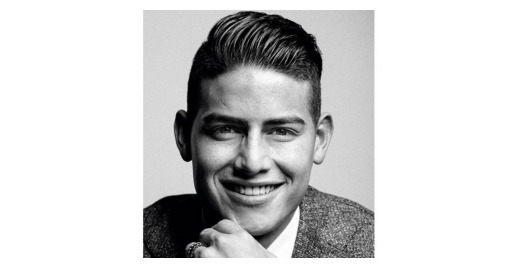

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import requests
from io import BytesIO

# URL de la imagen
url = "https://imagenes2.eltiempo.com/files/image_1200_600/uploads/2019/02/22/5c705c61605df.jpeg"

# Leer la imagen utilizando requests y Pillow
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar la imagen para confirmar que cargó correctamente
plt.imshow(img)
plt.axis('off') # Ocultar los ejes
plt.show()

In [3]:
# Convertir la imagen de Pillow a un arreglo de NumPy
img_array = np.array(img)

# Imprimir el arreglo
print("Arreglo de la imagen:")
print(img_array)

# Ver las dimensiones del arreglo (Alto, Ancho, Canales)
print(f"\nDimensiones de la matriz: {img_array.shape}")

Arreglo de la imagen:
[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [255 255 255]]]

Dimensiones de la matriz: (600, 1200, 3)


Dimensiones de la imagen recortada: (600, 500, 3)


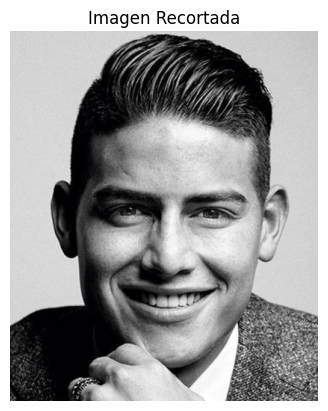

In [4]:
# Convertimos la imagen a un arreglo de numpy (si no lo has hecho)
img_array = np.array(img)

# Extraer el recorte: 
# Desde la fila 0 a la 330
# Desde la columna 600 a la 830
img_recortada = img_array[0:600, 330:830]

# Verificamos las dimensiones del recorte
print(f"Dimensiones de la imagen recortada: {img_recortada.shape}")

# Mostrar el resultado
plt.imshow(img_recortada)
plt.title("Imagen Recortada")
plt.axis('off')
plt.show()


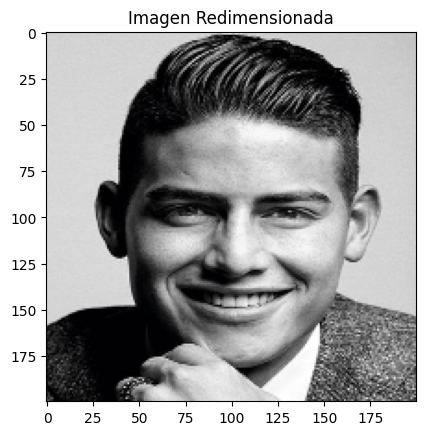

Dimensiones de la imagen redimensionada: (200, 200, 3)


In [5]:
# la imagen recortada disminuyala a 200x200 píxeles  ponga el axys on y muestre el shape
# Redimensionar la imagen recortada a 200x200 píxeles
img_redimensionada = cv2.resize(img_recortada, (200, 200))
# Mostrar la imagen redimensionada
plt.imshow(img_redimensionada)
plt.title("Imagen Redimensionada")
plt.axis('on')  # Mostrar los ejes
plt.show()
# Mostrar las dimensiones de la imagen redimensionada
print(f"Dimensiones de la imagen redimensionada: {img_redimensionada.shape}")

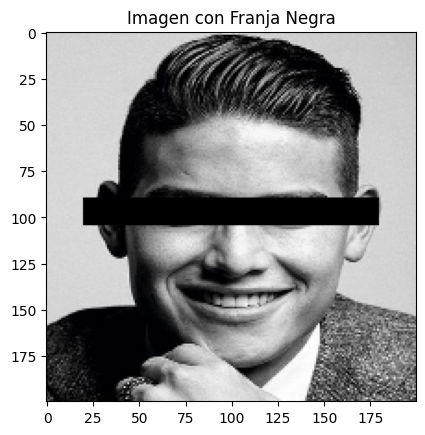

Dimensiones de la imagen con franja: (200, 200, 3)


In [6]:
# Definir la ubicación y el tamaño de la franja (en píxeles)
# NOTA: Estas coordenadas son aproximadas. Quizás necesites ajustarlas
# dependiendo de dónde estén los ojos en tu recorte original.
# Formato: img[fila_inicio:fila_fin, columna_inicio:columna_fin]
fila_inicio = 90
fila_fin = 105
columna_inicio = 20    # Empezar cerca del borde izquierdo
columna_fin = 180      # Terminar cerca del borde derecho

# Asignar el valor negro (0) a esa sección para todos los canales de color
# El negro se representa como [0, 0, 0] para RGB
img_con_franja = img_redimensionada.copy() # Hacemos una copia para no alterar la original
img_con_franja[fila_inicio:fila_fin, columna_inicio:columna_fin] = [0, 0, 0]

# --- FIN DEL NUEVO CÓDIGO ---

# Mostrar la imagen resultante
plt.imshow(img_con_franja)
plt.title("Imagen con Franja Negra")
plt.axis('on')  # Mostrar los ejes (píxeles)
plt.show()

# Verificamos que las dimensiones sigan siendo las mismas
print(f"Dimensiones de la imagen con franja: {img_con_franja.shape}")

# Procesamiento de imágenes a color

## Operaciones con las capas del arreglo a colores

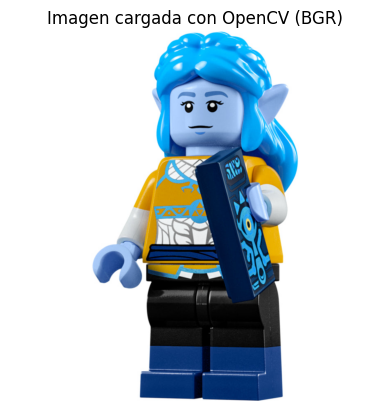

Dimensiones: (904, 904, 3) dtype: uint8


In [9]:
# Cargar la imagen con OpenCV desde la URL (sin convertir a RGB)
resp = requests.get('https://tiendalego.com.co/cdn/shop/files/77092-3_b8dae18b-a682-498a-b73a-0c89a355019b_904x904.jpg')
img_data = np.frombuffer(resp.content, dtype=np.uint8)
img_bgr_from_url = cv2.imdecode(img_data, cv2.IMREAD_COLOR)

# Mostrar con matplotlib directamente (queda en BGR)
plt.imshow(img_bgr_from_url)
plt.axis("off")
plt.title("Imagen cargada con OpenCV (BGR)")
plt.show()

print("Dimensiones:", img_bgr_from_url.shape, "dtype:", img_bgr_from_url.dtype)

Forma de la imagen RGB: (904, 904, 3)


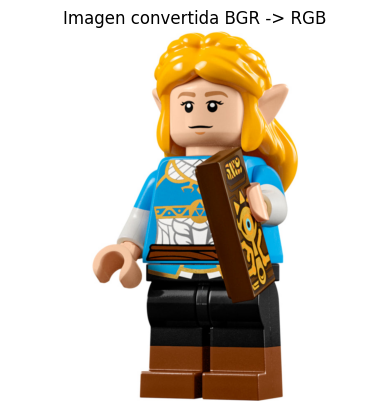

In [11]:
# Leer la imagen desde URL con requests + OpenCV
resp = requests.get('https://tiendalego.com.co/cdn/shop/files/77092-3_b8dae18b-a682-498a-b73a-0c89a355019b_904x904.jpg')
img_data = np.frombuffer(resp.content, dtype=np.uint8)
img_bgr = cv2.imdecode(img_data, cv2.IMREAD_COLOR)

# Convertir de BGR a RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Mostrar la forma
print("Forma de la imagen RGB:", img_rgb.shape)

# Mostrar imagen
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Imagen convertida BGR -> RGB")
plt.show()

Shape de la imagen en escala de grises: (904, 904)


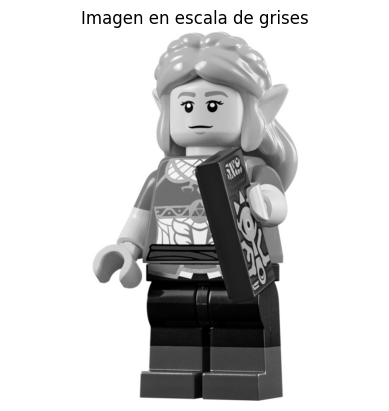

In [12]:
# Convertir img_rgb a escala de grises
img_gris = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Mostrar shape
print("Shape de la imagen en escala de grises:", img_gris.shape)

# Mostrar imagen en escala de grises
plt.imshow(img_gris, cmap='gray')
plt.axis('off')
plt.title("Imagen en escala de grises")
plt.show()

Shape capa0: (904, 904)


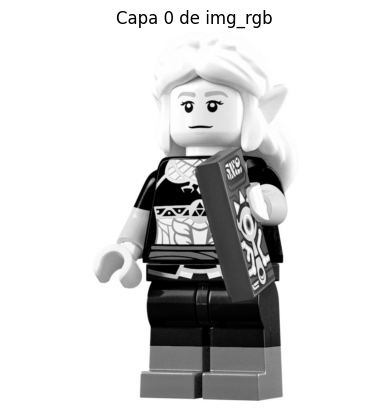

In [13]:
# Seleccionar la capa 0 (canal R en img_rgb) de la imagen
capa0 = img_rgb[:, :, 0]

# Mostrar shape y la imagen en escala de grises de esa capa
print("Shape capa0:", capa0.shape)

plt.imshow(capa0, cmap='gray')
plt.axis('off')
plt.title("Capa 0 de img_rgb")
plt.show()

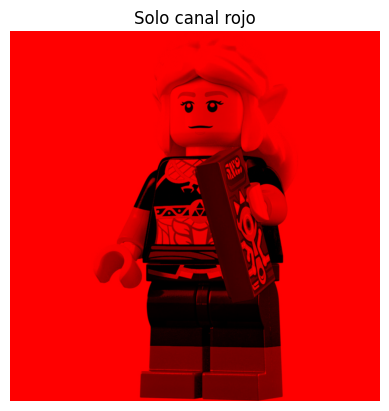

Shape: (904, 904, 3) dtype: uint8


In [14]:
# Mantener solo la capa roja en img_rgb y poner verde/azul en cero
img_rojo = img_rgb.copy()
img_rojo[:, :, 1] = 0  # canal G
img_rojo[:, :, 2] = 0  # canal B

plt.imshow(img_rojo)
plt.axis('off')
plt.title('Solo canal rojo')
plt.show()

print("Shape:", img_rojo.shape, "dtype:", img_rojo.dtype)

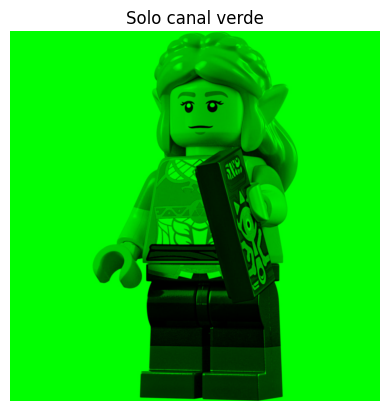

Shape: (904, 904, 3) dtype: uint8


In [15]:
# Mantener solo la capa verde en img_rgb (G) y poner rojo/azul en cero
img_verde = img_rgb.copy()
img_verde[:, :, 0] = 0  # canal R
img_verde[:, :, 2] = 0  # canal B

plt.imshow(img_verde)
plt.axis('off')
plt.title('Solo canal verde')
plt.show()

print("Shape:", img_verde.shape, "dtype:", img_verde.dtype)

# observacion
 **una convolucion es tomar una matriz y multiplicarla pr una mas grande**

**Un kernel es una matriz pequeña que generalmente es impar, solo puede tomar valores entre -6 y 6**



Shape de la imagen (alto, ancho, canales): (1069, 1900, 3)


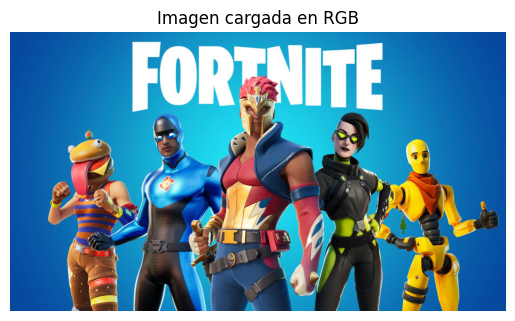

In [16]:
import requests
from PIL import Image
from io import BytesIO

url = 'https://fotografias-neox.atresmedia.com/clipping/cmsimages02/2020/11/09/FDAD0B9D-4486-4CE7-9C2B-6CC195BA1977/98.jpg'
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')

img_array = np.array(img)

print('Shape de la imagen (alto, ancho, canales):', img_array.shape)

plt.imshow(img_array)
plt.axis('off')
plt.title('Imagen cargada en RGB')
plt.show()

In [17]:
#cree una matriz con los siguientes valores[[2,1,-2,0,-1],[3,-3,2,5,4],[-2,0,1,2,2],[4,-5,3,2,0],[1,4,3,0,1]] y el kernel se llama Ardila
Ardila = np.array([[2, 1, -2, 0, -1],
                   [3, -3, 2, 5, 4],        
                   [-2, 0, 1, 2, 2],        
                   [4, -5, 3, 2, 0],        
                   [1, 4, 3, 0, 1]])
print("Kernel Ardila:")
print(Ardila)
        

Kernel Ardila:
[[ 2  1 -2  0 -1]
 [ 3 -3  2  5  4]
 [-2  0  1  2  2]
 [ 4 -5  3  2  0]
 [ 1  4  3  0  1]]


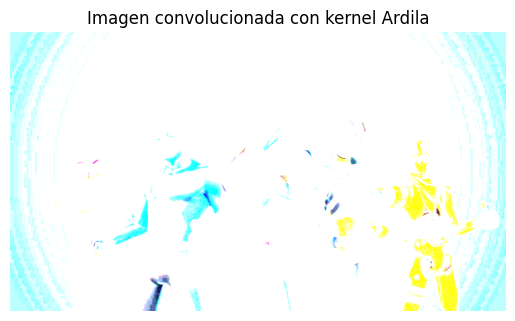

Shape de la imagen convolucionada: (1069, 1900, 3)


In [19]:
# Utilice el kernel Ardila y haga una operacion convolucional usando la libreria de opencv llamada filter2D, imprima la imagen resultante y muestre su shape
# Aplicar la operación de convolución con el kernel Ardila
img_convolucionada = cv2.filter2D(img_array, -1, Ardila)
# Mostrar la imagen resultante
plt.imshow(img_convolucionada)
plt.title("Imagen convolucionada con kernel Ardila")
plt.axis('off')
plt.show()
# Mostrar el shape de la imagen resultante
print("Shape de la imagen convolucionada:", img_convolucionada.shape)






In [22]:
# cambie los valores de la variable kernel ardila  por una matriz de 5x5 con el mismo nombre con  todos valores internos lleno de 1/25 y muestreme la matriz Ardila
Ardila = np.ones((5, 5)) / 25
print("Kernel Ardila modificado (todos valores 1/25):")
print(Ardila)


Kernel Ardila modificado (todos valores 1/25):
[[0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]
 [0.04 0.04 0.04 0.04 0.04]]


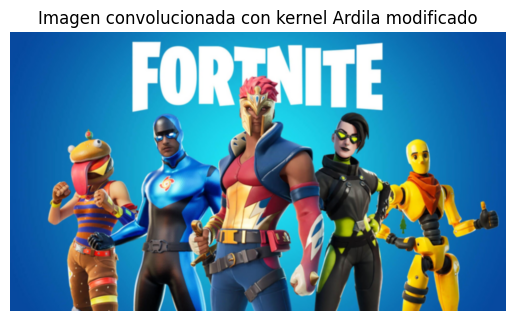

Shape de la imagen convolucionada: (1069, 1900, 3)


In [23]:
# multiplique la imagen original por el kernel ardila modificado y muestre la imagen resultante y su shape
img_convolucionada_modificada = cv2.filter2D(img_array, -1, Ardila)
# Mostrar la imagen resultante
plt.imshow(img_convolucionada_modificada)
plt.title("Imagen convolucionada con kernel Ardila modificado")
plt.axis('off')
plt.show()
# Mostrar el shape de la imagen resultante
print("Shape de la imagen convolucionada:", img_convolucionada_modificada.shape)


In [25]:
# Aplicar padding a la imagen
img_padded = cv2.copyMakeBorder(img_array, 1, 1, 1, 1, cv2.BORDER_REPLICATE)
print(f"Shape de la imagen con padding: {img_padded.shape}")

Shape de la imagen con padding: (1071, 1902, 3)


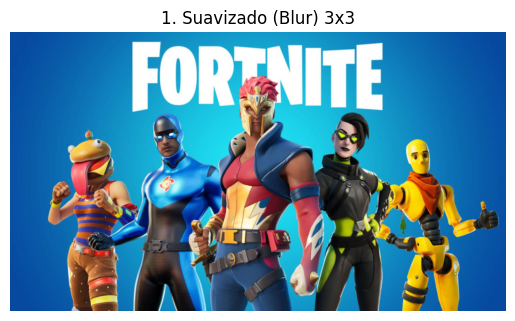

Shape imagen suavizada: (1069, 1900, 3)


In [26]:
# 1. Suavizado (Blur) con kernel 3x3
kernel_blur = np.ones((3, 3)) / 9
img_blur = cv2.filter2D(img_array, -1, kernel_blur)
plt.imshow(img_blur)
plt.title("1. Suavizado (Blur) 3x3")
plt.axis('off')
plt.show()
print(f"Shape imagen suavizada: {img_blur.shape}")

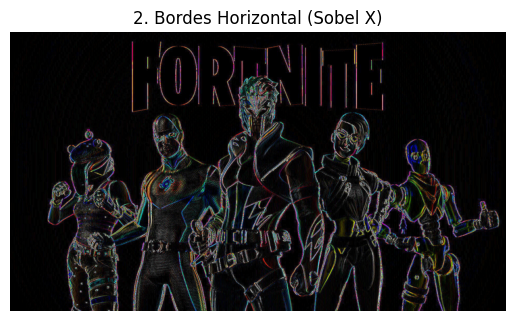

Shape bordes horizontal: (1069, 1900, 3)


In [27]:
# 2. Detección de bordes horizontal usando Sobel
sobelX = cv2.Sobel(img_array, cv2.CV_64F, 1, 0, ksize=3)
sobelX = np.uint8(np.absolute(sobelX))
plt.imshow(sobelX, cmap='gray')
plt.title("2. Bordes Horizontal (Sobel X)")
plt.axis('off')
plt.show()
print(f"Shape bordes horizontal: {sobelX.shape}")

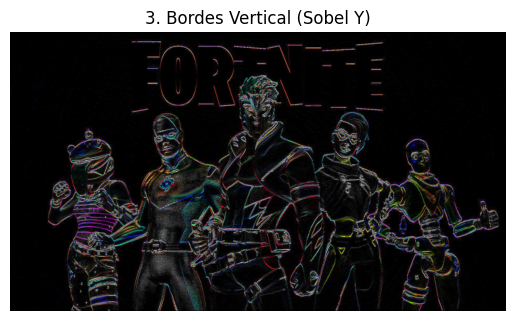

Shape bordes vertical: (1069, 1900, 3)


In [28]:
# 3. Detección de bordes vertical usando Sobel
sobelY = cv2.Sobel(img_array, cv2.CV_64F, 0, 1, ksize=3)
sobelY = np.uint8(np.absolute(sobelY))
plt.imshow(sobelY, cmap='gray')
plt.title("3. Bordes Vertical (Sobel Y)")
plt.axis('off')
plt.show()
print(f"Shape bordes vertical: {sobelY.shape}")

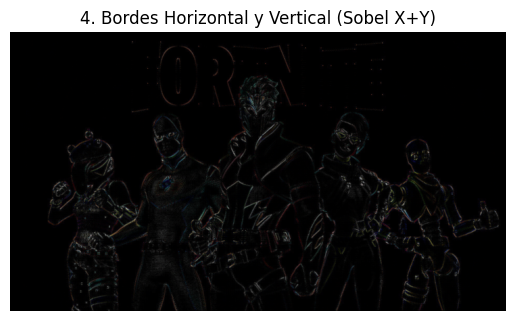

Shape bordes combinados: (1069, 1900, 3)


In [29]:
# 4. Detección de bordes horizontal y vertical combinados (magnitud de gradientes)
sobelXY = cv2.Sobel(img_array, cv2.CV_64F, 1, 1, ksize=3)
sobelXY = np.uint8(np.absolute(sobelXY))
plt.imshow(sobelXY, cmap='gray')
plt.title("4. Bordes Horizontal y Vertical (Sobel X+Y)")
plt.axis('off')
plt.show()
print(f"Shape bordes combinados: {sobelXY.shape}")

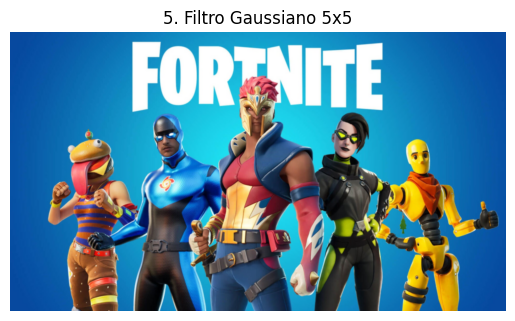

Shape Gaussiano: (1069, 1900, 3)


In [30]:
# 5. Filtro Gaussiano con kernel 5x5
img_gaussian = cv2.GaussianBlur(img_array, (5, 5), 0)
plt.imshow(img_gaussian)
plt.title("5. Filtro Gaussiano 5x5")
plt.axis('off')
plt.show()
print(f"Shape Gaussiano: {img_gaussian.shape}")

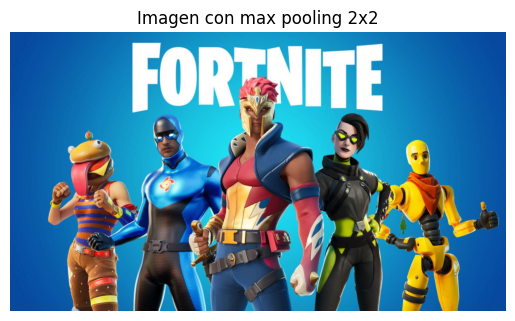

Shape de la imagen con max pooling: (534, 950, 3)


In [31]:
#tomar la imagen original  y haga un max pooling de 2x2, me muestra la imagen y me muestra el shape.
img_max_pooling = cv2.resize(img_array, (img_array.shape[1]//2, img_array.shape[0]//2), interpolation=cv2.INTER_AREA)
plt.imshow(img_max_pooling)
plt.title("Imagen con max pooling 2x2")
plt.axis('off')
plt.show()
print(f"Shape de la imagen con max pooling: {img_max_pooling.shape}")



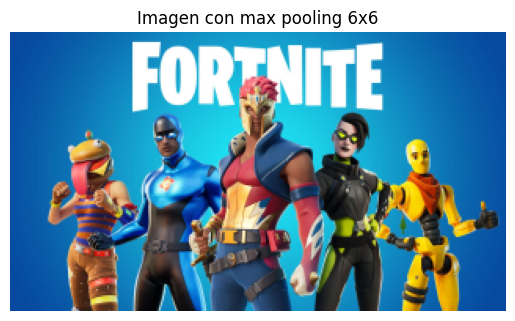

Shape de la imagen con max pooling: (178, 316, 3)


In [32]:
# ahora toma la imagen original y haga un max pooling de 6x6, me muestra la imagen y me muestra el shape.
img_max_pooling_6x6 = cv2.resize(img_array, (img_array.shape[1]//6, img_array.shape[0]//6), interpolation=cv2.INTER_AREA)
plt.imshow(img_max_pooling_6x6)
plt.title("Imagen con max pooling 6x6")
plt.axis('off')
plt.show()
print(f"Shape de la imagen con max pooling: {img_max_pooling_6x6.shape}")
